# TESTANDO COM NOVA BASE DE DADOS

1. Importar Bibliotecas e Carregar Dados

In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Carregar dados do Excel
df = pd.read_excel('insumos_vendidos_por_dia_fixed.xlsx')

2. Pré-processamento e Feature Engineering

In [51]:
# Converter coluna 'Data' para datetime e extrair features temporais
df['Data'] = pd.to_datetime(df['Data'])
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia'] = df['Data'].dt.day
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo

# Adicionar variáveis relevantes
# 1. Feriados (exemplo para Brasil)
feriados = ['2024-01-01', '2024-04-21', '2024-12-25', '2025-01-01']  # Adapte com suas datas
df['Feriado'] = df['Data'].isin(pd.to_datetime(feriados)).astype(int)

# 2. Fim de semana
df['Fim_de_Semana'] = df['Dia_Semana'].isin([5, 6]).astype(int)  # 5=Sábado, 6=Domingo

# 3. Média móvel de 7 dias (para 'ARR')
df['ARR_Media_7d'] = df['ARR'].rolling(window=7).mean().shift(1)  # Usa dados passados

# Remover linhas com NaN (geradas pela média móvel)
df = df.dropna()

3. Seleção de Features e Target

In [52]:
# Selecionar colunas de insumos (excluindo datas e colunas não numéricas)
insumos = df.columns[1:18]  # Colunas de 'ARR' até 'TUTU'

# Definir features (X) e target (y) para um insumo (ex: ARR)
features = ['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Feriado', 'Fim_de_Semana', 'ARR_Media_7d']
X = df[features]
y = df['ARR']  # Alvo: vendas do insumo ARR

4. Divisão dos Dados e Treinamento do Modelo

In [53]:
# Dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Treinar modelo (Random Forest como exemplo)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Previsões
y_pred = model.predict(X_test)

5. Avaliação do Modelo

In [54]:
# Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

# Importância das features
importancias = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportância das Features:")
print(importancias)

MAE: 1737.98
R²: 0.33

Importância das Features:
Dia_Semana       0.362333
ARR_Media_7d     0.285963
Dia              0.227147
Fim_de_Semana    0.059850
Mes              0.048001
Ano              0.016707
Feriado          0.000000
dtype: float64


6. Visualização dos Resultados

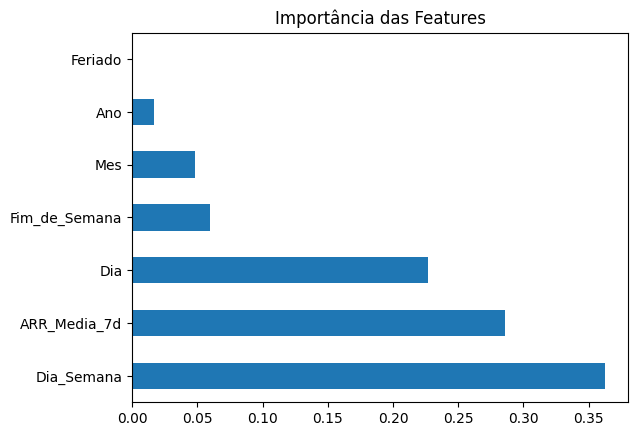

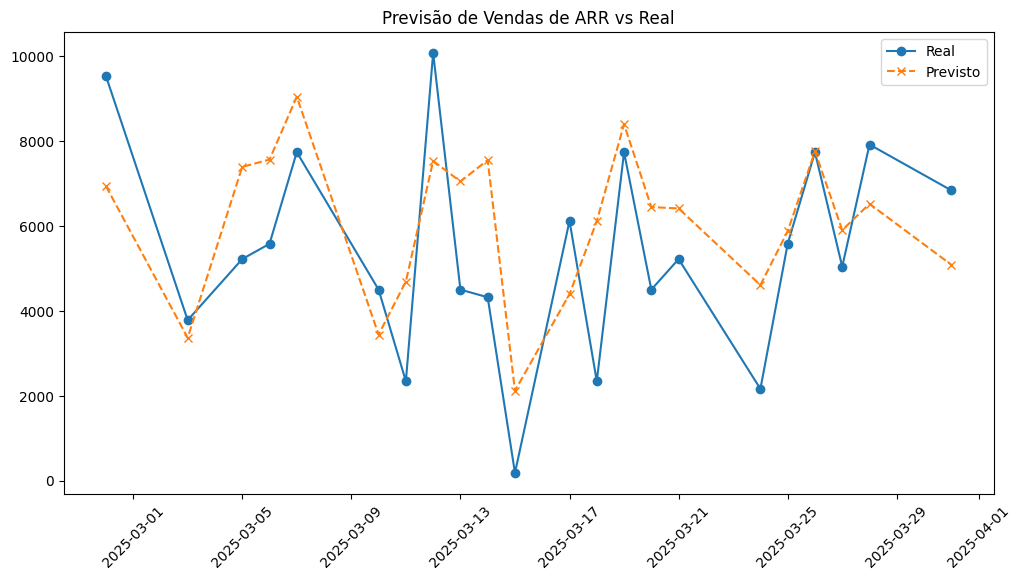

In [55]:
# Gráfico de importância das features
importancias.plot(kind='barh', title='Importância das Features')
plt.show()

# Comparação entre valores reais e previstos
plt.figure(figsize=(12, 6))
plt.plot(df['Data'][-len(y_test):], y_test, label='Real', marker='o')
plt.plot(df['Data'][-len(y_test):], y_pred, label='Previsto', linestyle='--', marker='x')
plt.title('Previsão de Vendas de ARR vs Real')
plt.legend()
plt.xticks(rotation=45)
plt.show()

7. Previsão para Futuros Dias

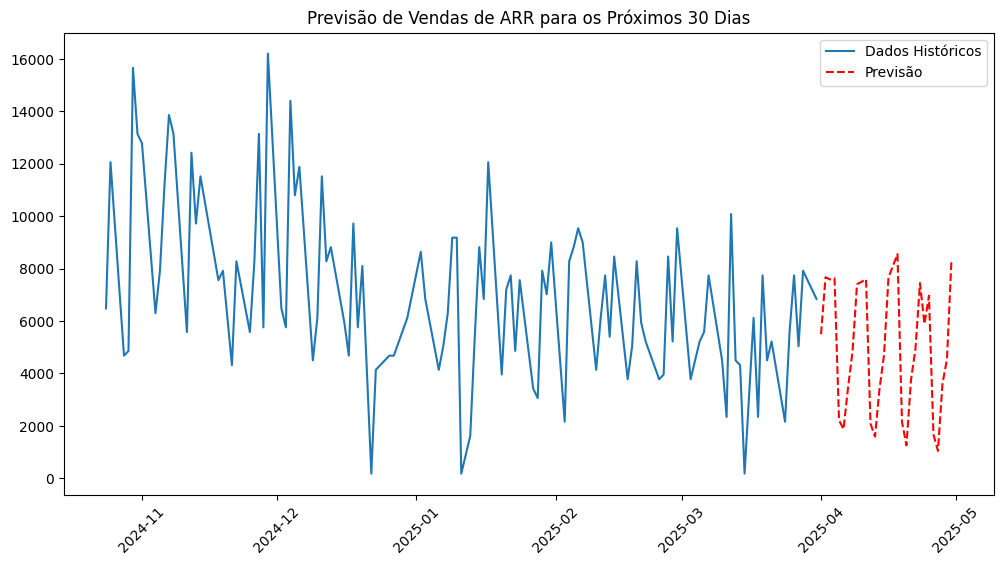

In [56]:
# Criar datas futuras (próximos 30 dias)
future_dates = pd.date_range(start=df['Data'].max() + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame({'Data': future_dates})

# Extrair features temporais para o futuro
future_df['Ano'] = future_df['Data'].dt.year
future_df['Mes'] = future_df['Data'].dt.month
future_df['Dia'] = future_df['Data'].dt.day
future_df['Dia_Semana'] = future_df['Data'].dt.dayofweek
future_df['Feriado'] = future_df['Data'].isin(pd.to_datetime(feriados)).astype(int)
future_df['Fim_de_Semana'] = future_df['Dia_Semana'].isin([5, 6]).astype(int)

# Calcular média móvel para o futuro (usando o último valor disponível)
last_7d_mean = df['ARR'].tail(7).mean()
future_df['ARR_Media_7d'] = last_7d_mean  # Simplificação (em produção, use uma lógica mais robusta)

# Prever
X_future = future_df[features]
future_df['ARR_Previsto'] = model.predict(X_future)

# Visualizar previsões
plt.figure(figsize=(12, 6))
plt.plot(df['Data'], df['ARR'], label='Dados Históricos')
plt.plot(future_df['Data'], future_df['ARR_Previsto'], label='Previsão', linestyle='--', color='red')
plt.title('Previsão de Vendas de ARR para os Próximos 30 Dias')
plt.legend()
plt.xticks(rotation=45)
plt.show()

1. Importar Bibliotecas e Carregar Dados

In [57]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Carregar dados do Excel
df = pd.read_excel('insumos_vendidos_por_dia_fixed.xlsx')

2. Pré-processamento e Feature Engineering

In [58]:
# Converter coluna 'Data' para datetime e extrair features temporais
df['Data'] = pd.to_datetime(df['Data'])
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia'] = df['Data'].dt.day
df['Dia_Semana'] = df['Data'].dt.dayofweek  # 0=Segunda, 6=Domingo

# Adicionar variáveis relevantes
feriados = ['2024-01-01', '2024-12-25', '2025-01-01']  # Adapte com suas datas
df['Feriado'] = df['Data'].isin(pd.to_datetime(feriados)).astype(int)
df['Fim_de_Semana'] = df['Dia_Semana'].isin([5, 6]).astype(int)

# Lista de insumos (colunas 2 a 18)
insumos = df.columns[1:18]  # ['ARR', 'BAC', 'BERIN', ..., 'TUTU']

3. Modelagem e Previsão para Cada Insumo

In [59]:
# Dicionário para armazenar resultados
resultados = {}

# Loop para cada insumo
for insumo in insumos:
    print(f"\n--- Modelando {insumo} ---")
    
    # Criar médias móveis (7 dias) para o insumo atual
    df[f'{insumo}_Media_7d'] = df[insumo].rolling(window=7).mean().shift(1)
    df_temp = df.dropna()  # Remover linhas com NaN
    
    # Definir features e target
    features = ['Ano', 'Mes', 'Dia', 'Dia_Semana', 'Feriado', 'Fim_de_Semana', f'{insumo}_Media_7d']
    X = df_temp[features]
    y = df_temp[insumo]
    
    # Dividir em treino (80%) e teste (20%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)
    
    # Treinar modelo (Random Forest)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    
    # Avaliar
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"MAE: {mae:.2f}, R²: {r2:.2f}")
    
    # Salvar resultados
    resultados[insumo] = {
        'modelo': model,
        'features': features,
        'mae': mae,
        'r2': r2
    }


--- Modelando ARR ---
MAE: 1737.98, R²: 0.33

--- Modelando BAC ---
MAE: 59.50, R²: 0.86

--- Modelando BERIN ---
MAE: 84.26, R²: 0.77

--- Modelando CARN ---
MAE: 412.81, R²: 0.76

--- Modelando COST ---
MAE: 90.05, R²: 0.85

--- Modelando COST S ---
MAE: 141.17, R²: 0.25

--- Modelando FEIJ ---
MAE: 1028.07, R²: 0.39

--- Modelando FEIJOA ---
MAE: 353.75, R²: 0.90

--- Modelando FRAL ---
MAE: 352.06, R²: 0.20

--- Modelando FRANG ---
MAE: 355.42, R²: 0.20

--- Modelando MAMI ---
MAE: 154.52, R²: -0.67

--- Modelando MASS ---
MAE: 618.91, R²: 0.02

--- Modelando MOLH ---
MAE: 274.47, R²: 0.16

--- Modelando MOLH B ---
MAE: 219.05, R²: 0.65

--- Modelando PEIX ---
MAE: 34.69, R²: 0.32

--- Modelando POL ---
MAE: 32.80, R²: 0.10

--- Modelando TUTU ---
MAE: 160.20, R²: 0.80


4. Previsão para os Próximos 30 Dias

In [60]:
# Criar datas futuras
future_dates = pd.date_range(start=df['Data'].max() + pd.Timedelta(days=1), periods=30, freq='D')
future_df = pd.DataFrame({'Data': future_dates})

# Extrair features temporais para o futuro
future_df['Ano'] = future_df['Data'].dt.year
future_df['Mes'] = future_df['Data'].dt.month
future_df['Dia'] = future_df['Data'].dt.day
future_df['Dia_Semana'] = future_df['Data'].dt.dayofweek
future_df['Feriado'] = future_df['Data'].isin(pd.to_datetime(feriados)).astype(int)
future_df['Fim_de_Semana'] = future_df['Dia_Semana'].isin([5, 6]).astype(int)

# Prever cada insumo
for insumo in insumos:
    features = resultados[insumo]['features']
    
    # Calcular média móvel futura (usando o último valor disponível)
    last_7d_mean = df[insumo].tail(7).mean()
    future_df[f'{insumo}_Media_7d'] = last_7d_mean
    
    # Prever
    X_future = future_df[features]
    future_df[f'{insumo}_Previsto'] = resultados[insumo]['modelo'].predict(X_future)

5. Visualização das Previsões

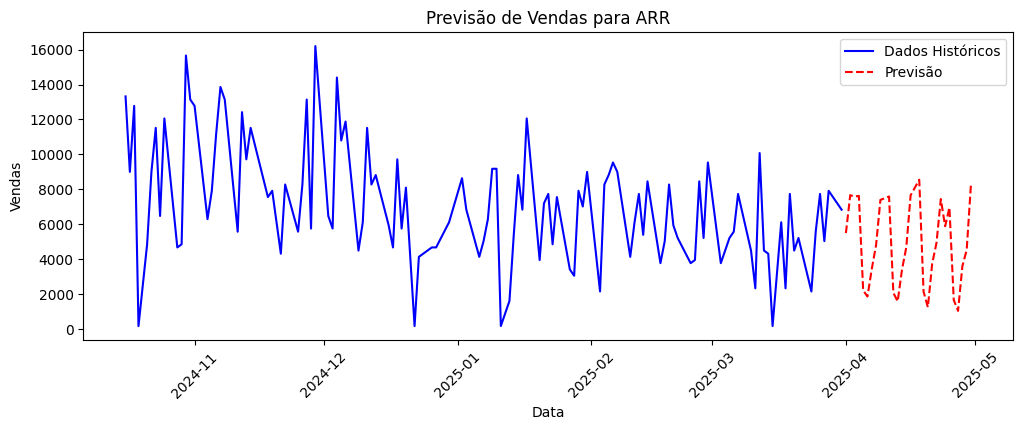

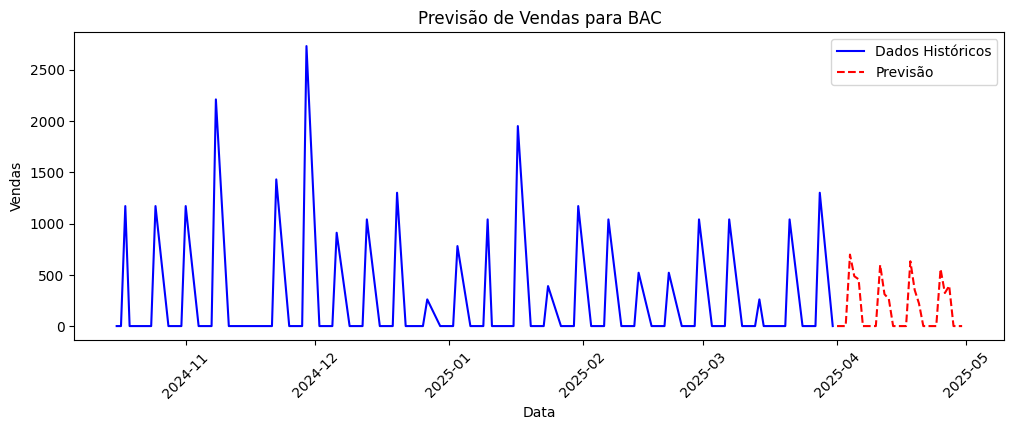

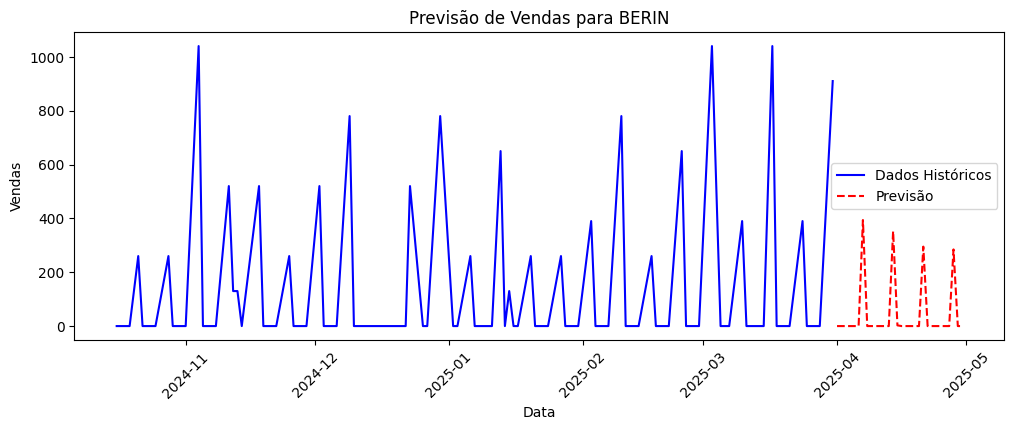

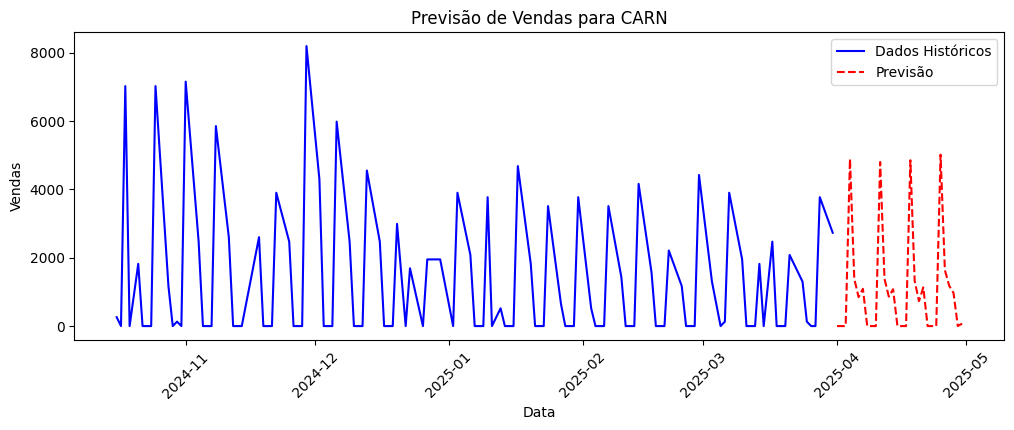

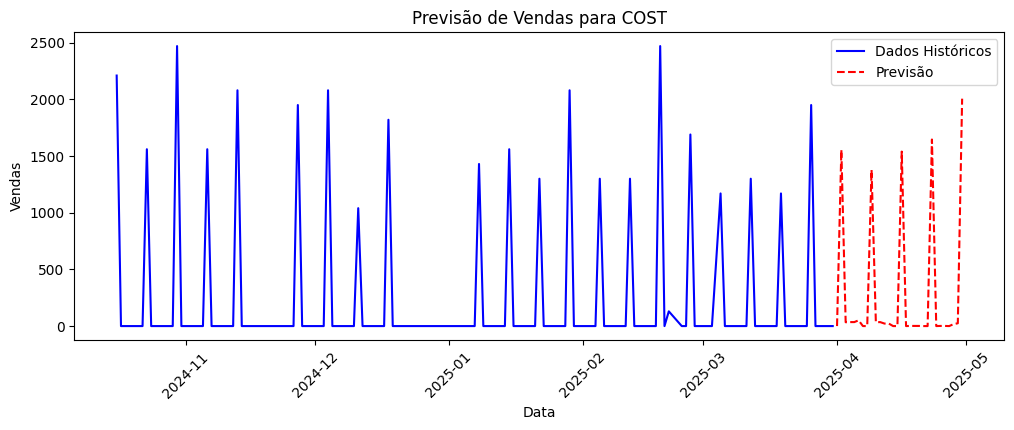

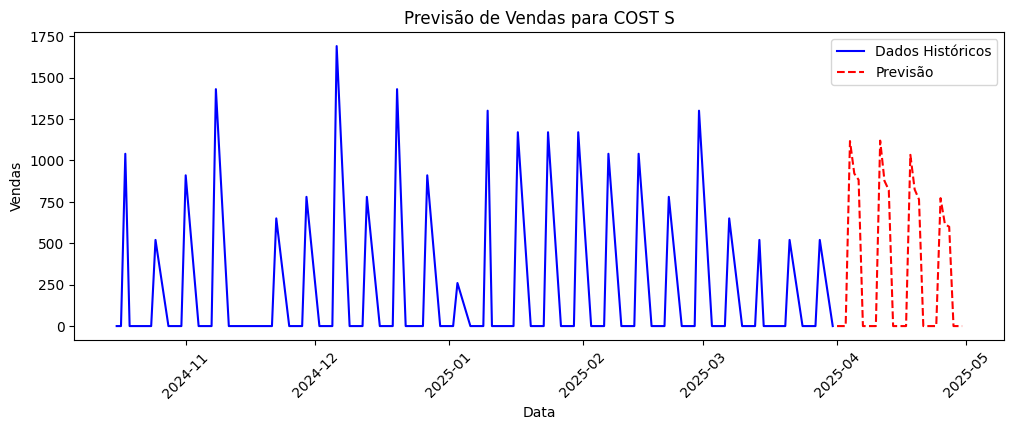

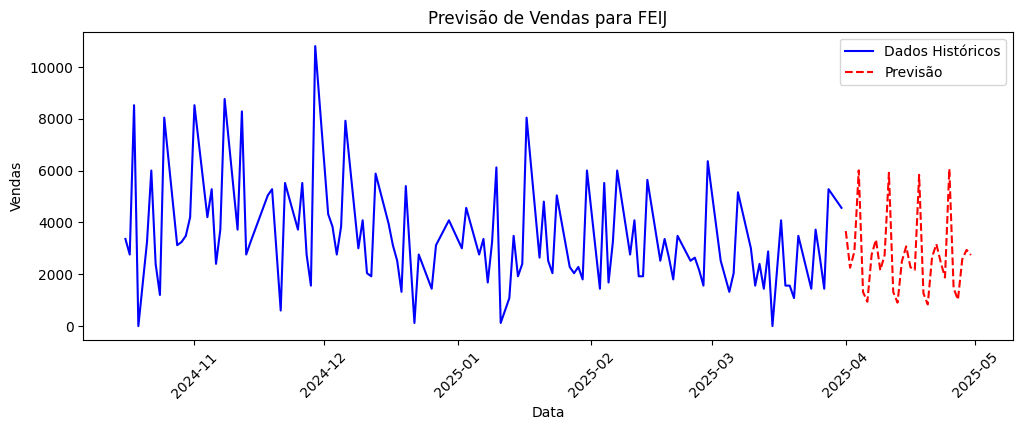

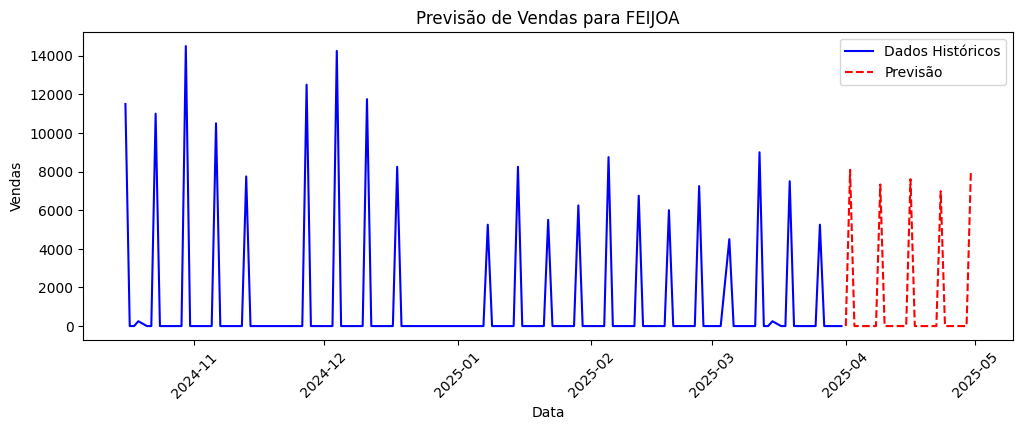

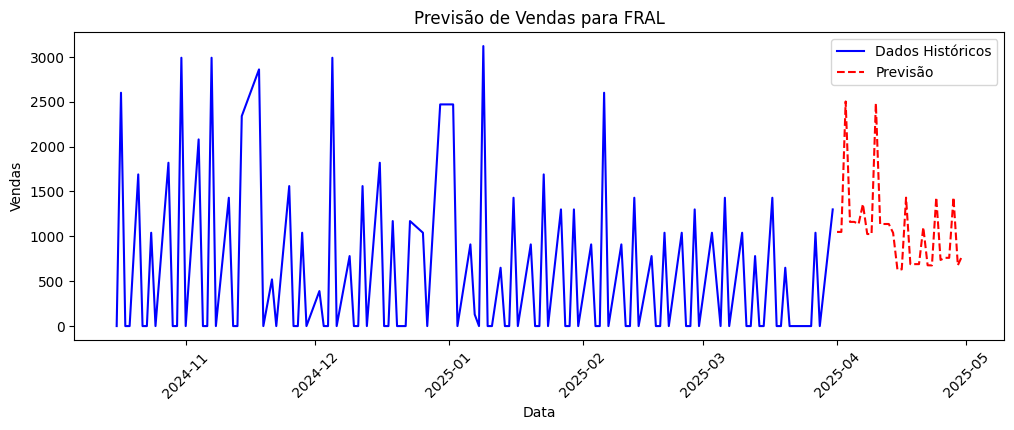

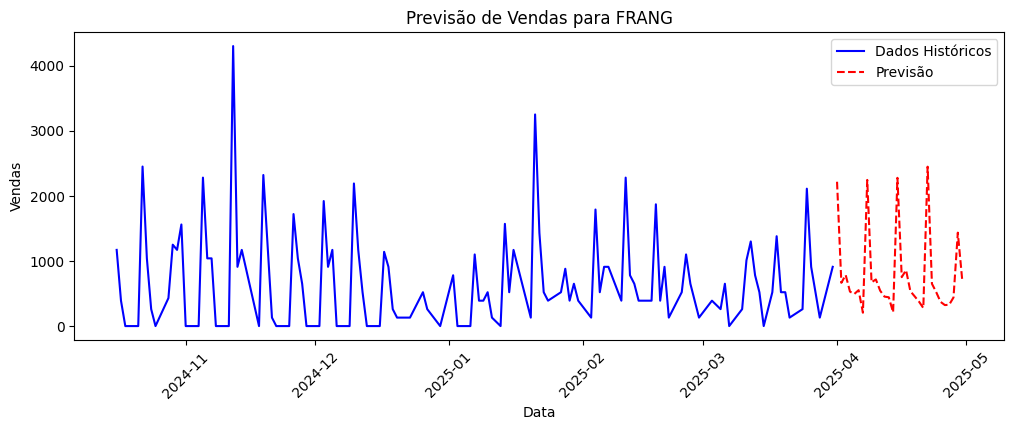

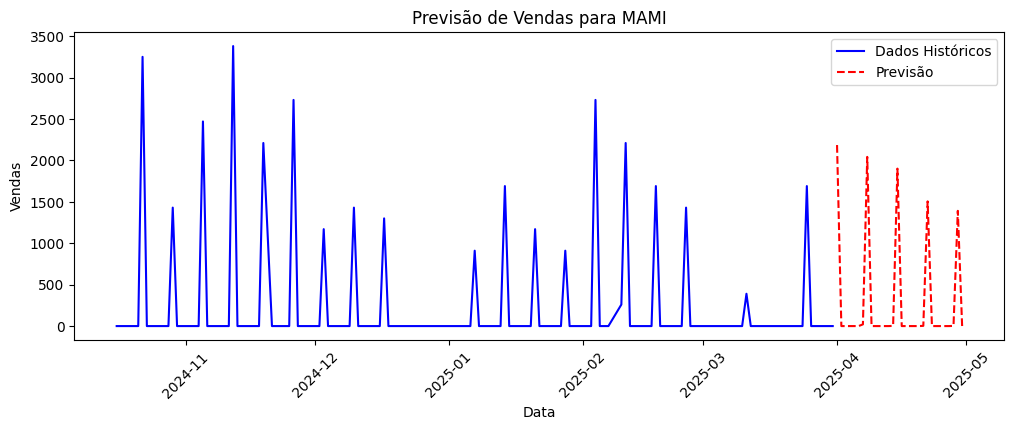

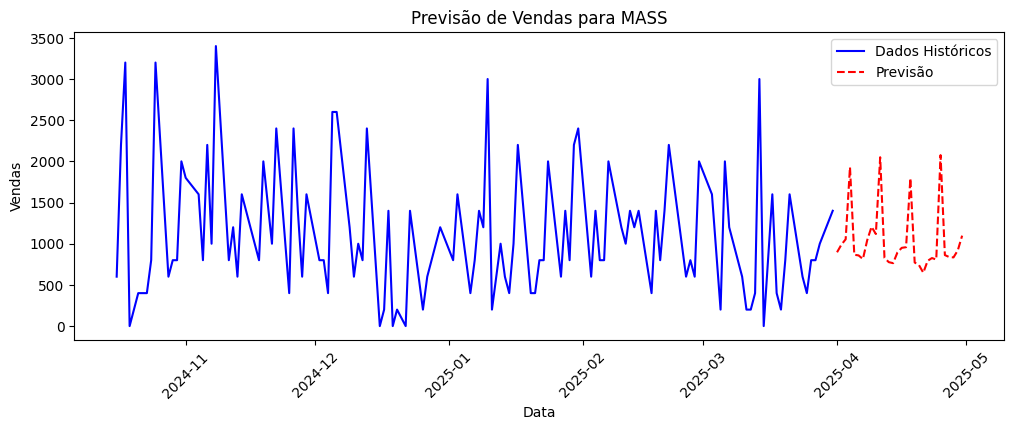

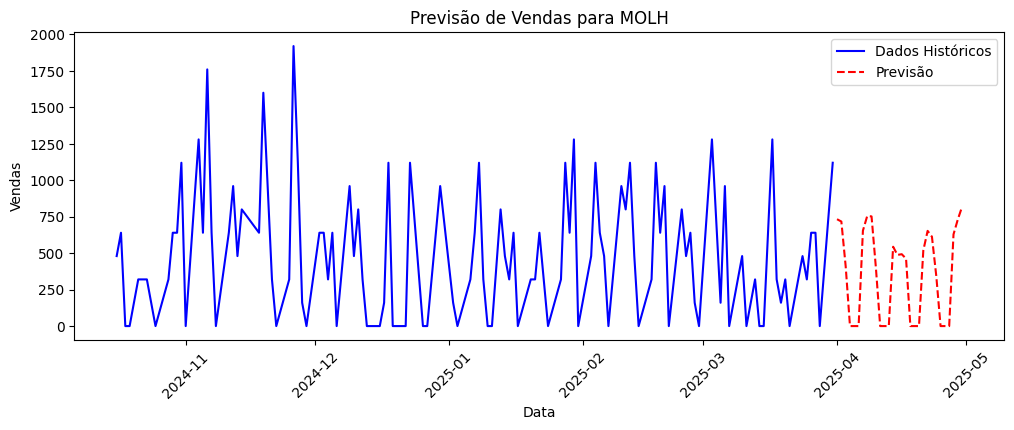

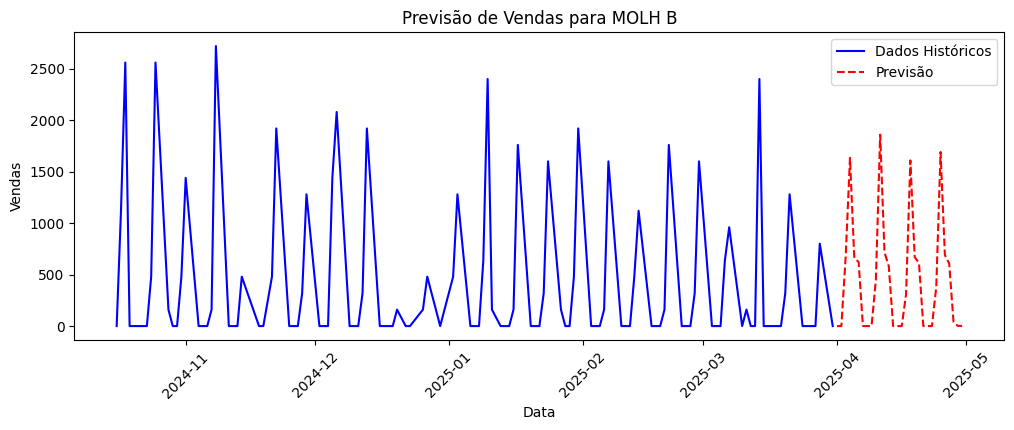

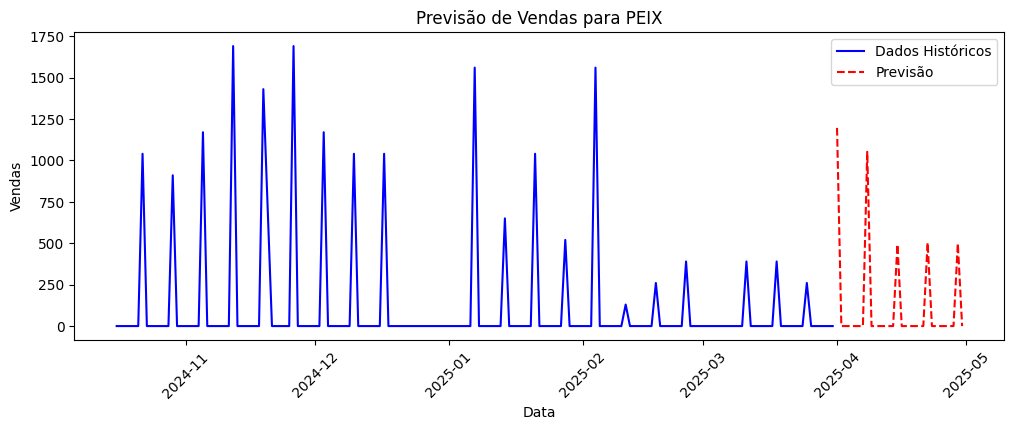

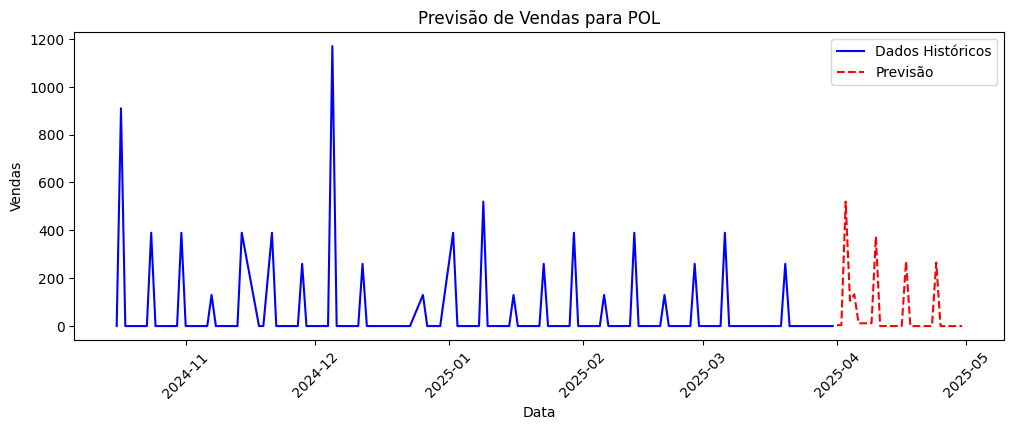

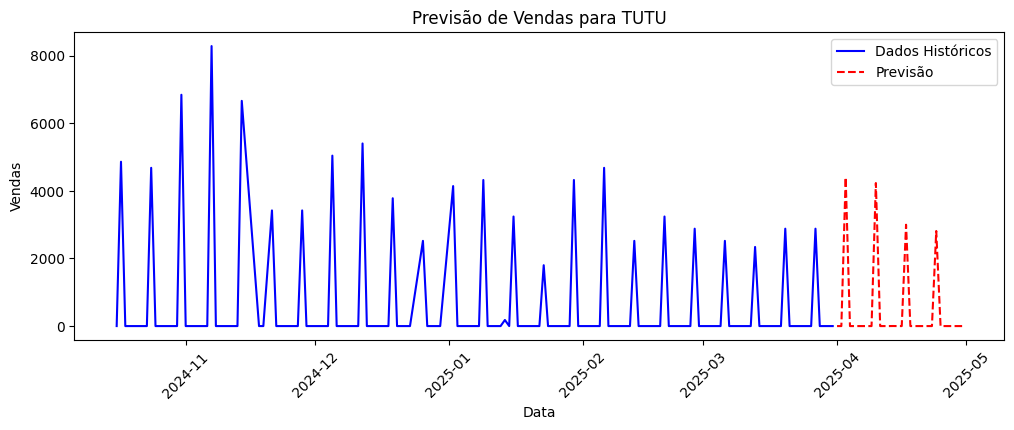

In [61]:
# Gráfico para cada insumo
for insumo in insumos:
    plt.figure(figsize=(12, 4))
    plt.plot(df['Data'], df[insumo], label='Dados Históricos', color='blue')
    plt.plot(future_df['Data'], future_df[f'{insumo}_Previsto'], label='Previsão', linestyle='--', color='red')
    plt.title(f'Previsão de Vendas para {insumo}')
    plt.xlabel('Data')
    plt.ylabel('Vendas')
    plt.legend()
    plt.xticks(rotation=45)
    plt.show()

Estilos disponíveis: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


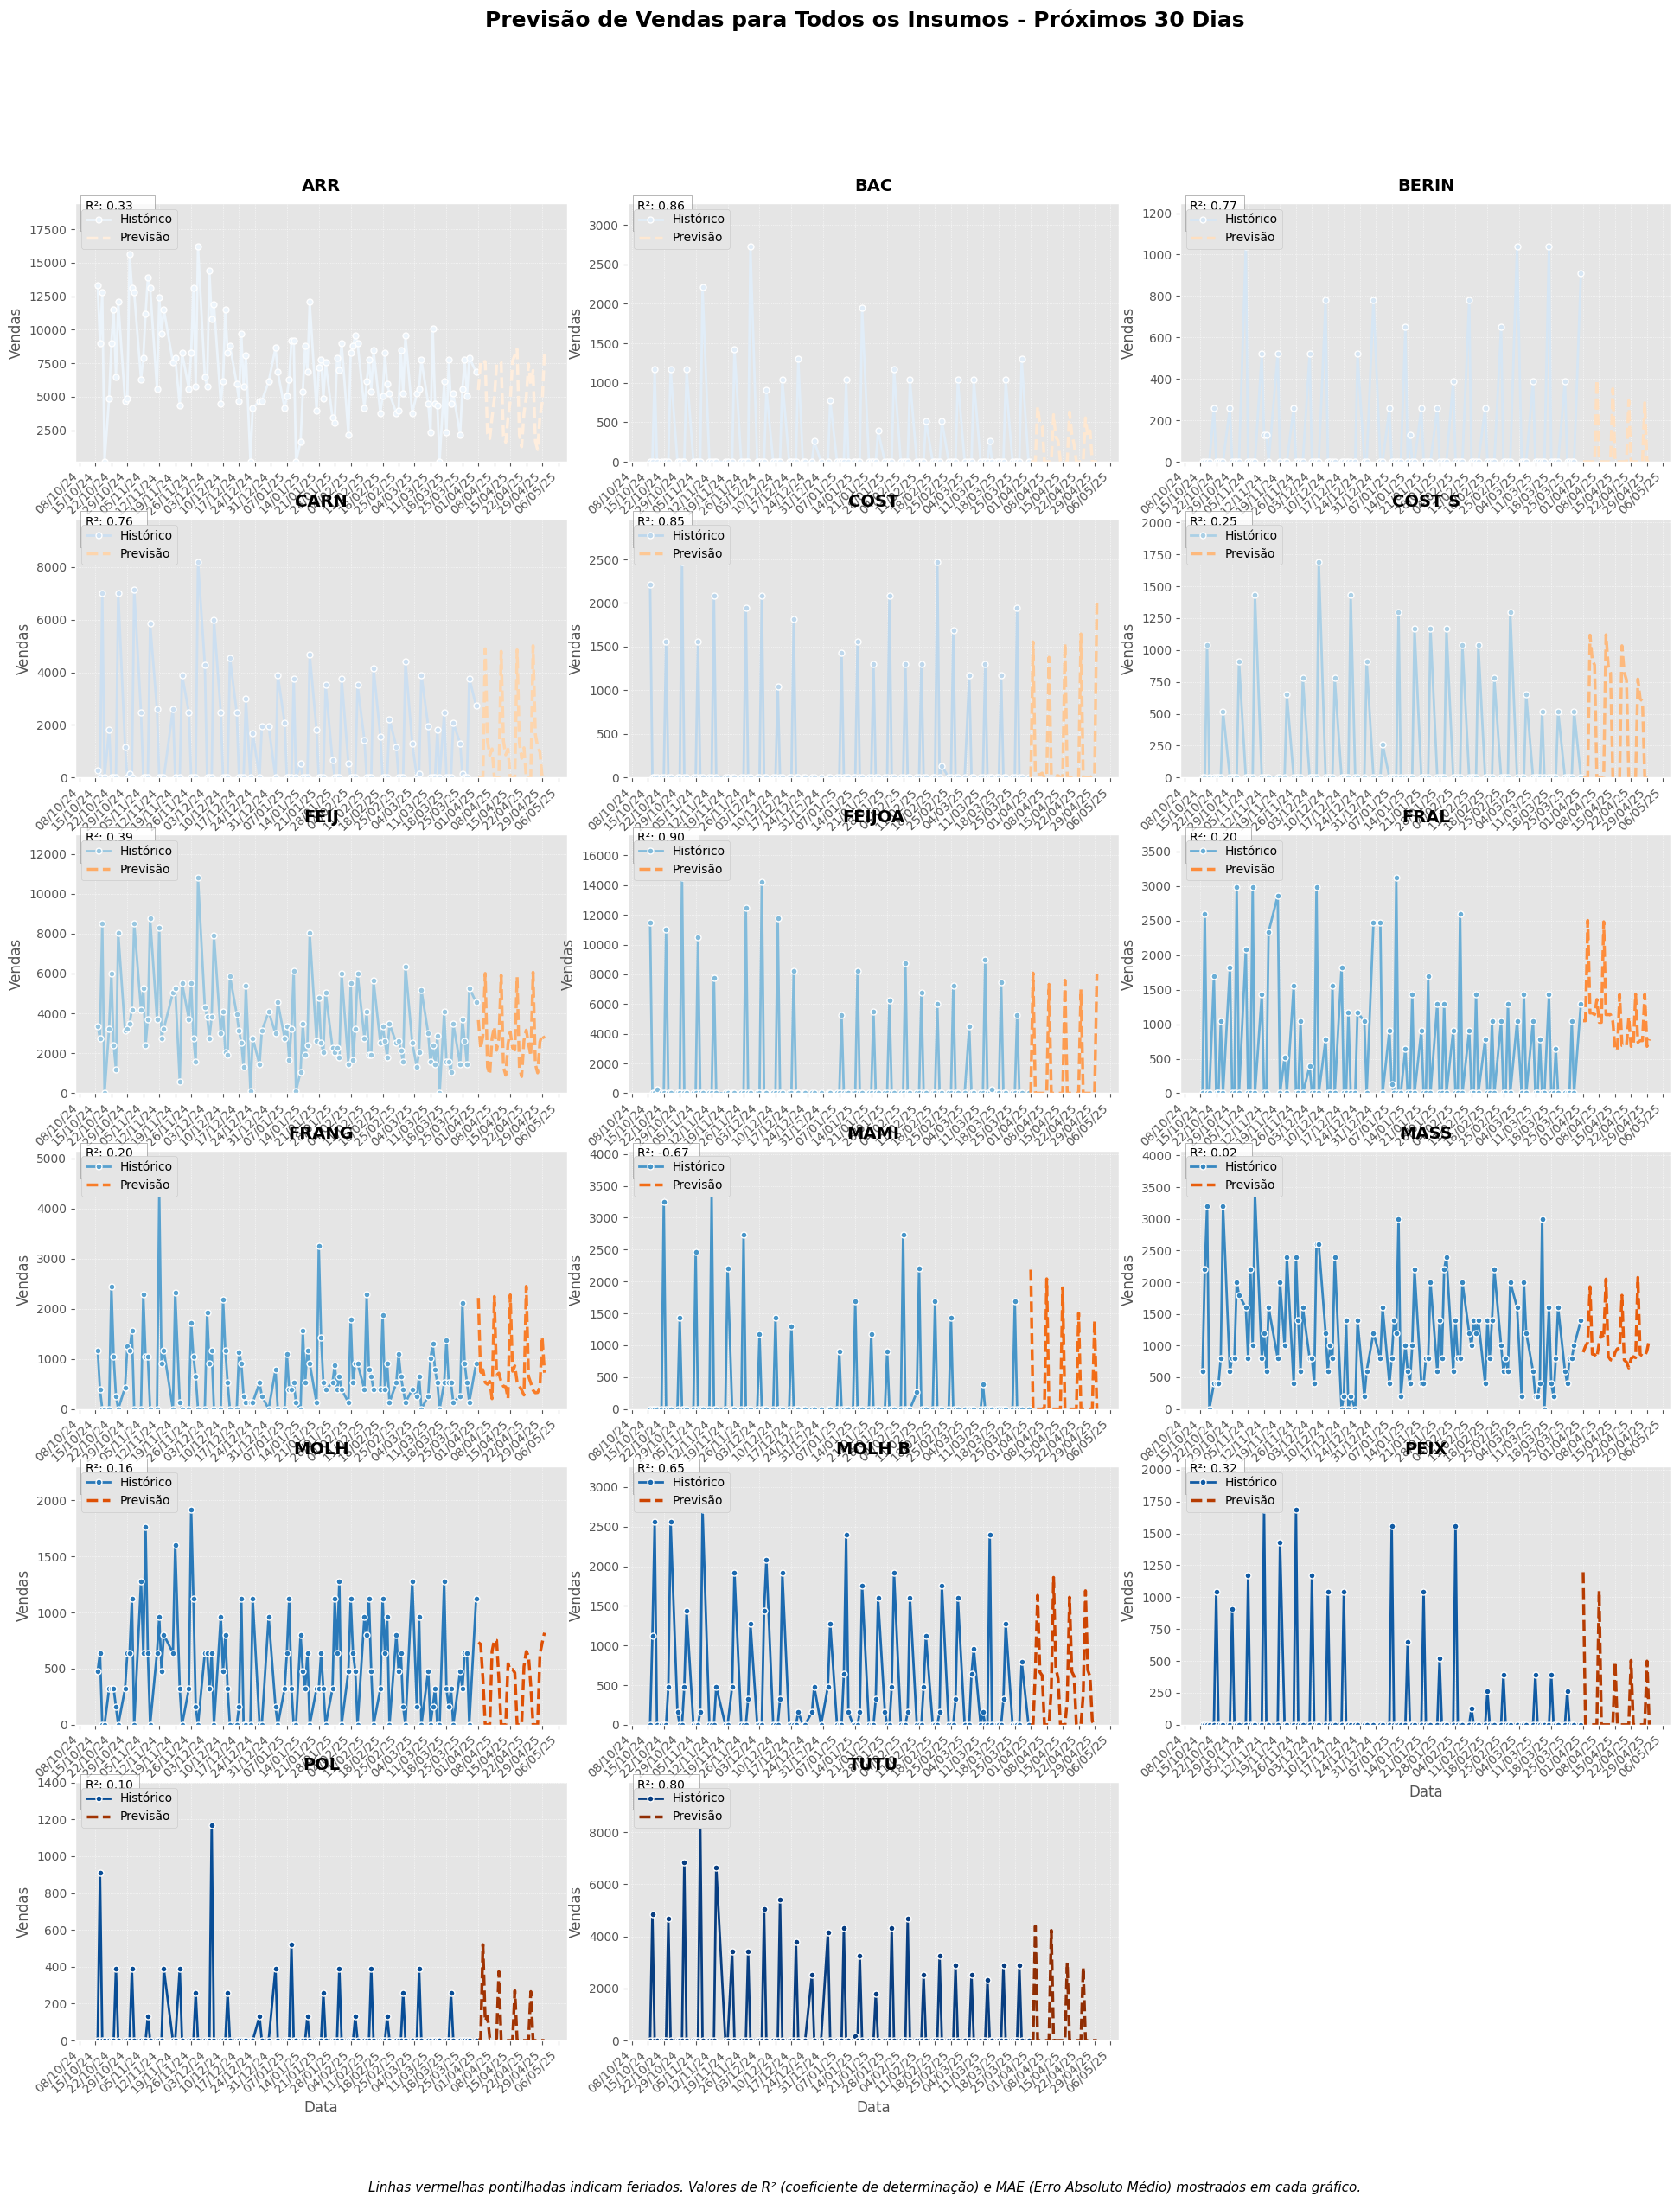

In [65]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import seaborn as sns  # Importando seaborn para ter acesso aos estilos

# Verificar estilos disponíveis e usar um adequado
print("Estilos disponíveis:", plt.style.available)
plt.style.use('ggplot')  # Usando um estilo que certamente está disponível

# Configurações gerais
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
sns.set_palette("husl")  # Usando uma paleta de cores agradável

# Criar figura com subplots
fig, axs = plt.subplots(6, 3, figsize=(20, 25))
fig.suptitle('Previsão de Vendas para Todos os Insumos - Próximos 30 Dias', 
             fontsize=18, y=1.02, fontweight='bold')

# Ajustar espaçamento
plt.tight_layout(pad=4.0, h_pad=3.0, w_pad=2.0)

# Paleta de cores
cores_historico = sns.color_palette("Blues", n_colors=len(insumos))
cores_previsao = sns.color_palette("Oranges", n_colors=len(insumos))

for idx, insumo in enumerate(insumos):
    ax = axs[idx//3, idx%3]
    
    # Dados históricos
    ax.plot(df['Data'], df[insumo], 
            label='Histórico',
            color=cores_historico[idx],
            linewidth=2,
            marker='o', markersize=5, markeredgecolor='white')
    
    # Previsões
    ax.plot(future_df['Data'], future_df[f'{insumo}_Previsto'], 
            label='Previsão',
            color=cores_previsao[idx],
            linestyle='--',
            linewidth=2.5)
    
    # Destacar feriados
    feriados_futuros = future_df[future_df['Feriado'] == 1]['Data']
    for data in feriados_futuros:
        ax.axvline(x=data, color='red', linestyle=':', alpha=0.7, linewidth=1.5)
    
    # Configurações do gráfico
    ax.set_title(insumo, fontsize=14, pad=10, fontweight='bold')
    ax.set_xlabel('Data', fontsize=12)
    ax.set_ylabel('Vendas', fontsize=12)
    
    # Formatar eixo x
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%y'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    
    # Limites do eixo y
    buffer = 0.2  # 20% de buffer
    y_min = min(df[insumo].min(), future_df[f'{insumo}_Previsto'].min()) * (1 - buffer)
    y_max = max(df[insumo].max(), future_df[f'{insumo}_Previsto'].max()) * (1 + buffer)
    ax.set_ylim(y_min, y_max)
    
    # Adicionar métricas
    ax.text(0.02, 0.92,
            f"R²: {resultados[insumo]['r2']:.2f}\nMAE: {resultados[insumo]['mae']:.0f}",
            transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))
    
    # Grade secundária
    ax.grid(True, which='both', linestyle=':', linewidth=0.5)
    ax.legend(loc='upper left', framealpha=1)

# Remover subplots vazios
for idx in range(len(insumos), 18):
    fig.delaxes(axs.flatten()[idx])

# Adicionar anotações
plt.figtext(0.5, 0.01,
            'Linhas vermelhas pontilhadas indicam feriados. Valores de R² (coeficiente de determinação) e MAE (Erro Absoluto Médio) mostrados em cada gráfico.',
            ha='center', fontsize=11, style='italic')

# Ajustar layout
plt.subplots_adjust(bottom=0.08, top=0.93)

# Salvar com alta qualidade
plt.savefig('previsoes_insumos_profissional.png',
            dpi=300,
            bbox_inches='tight',
            facecolor=fig.get_facecolor())

plt.show()

Estilos disponíveis: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


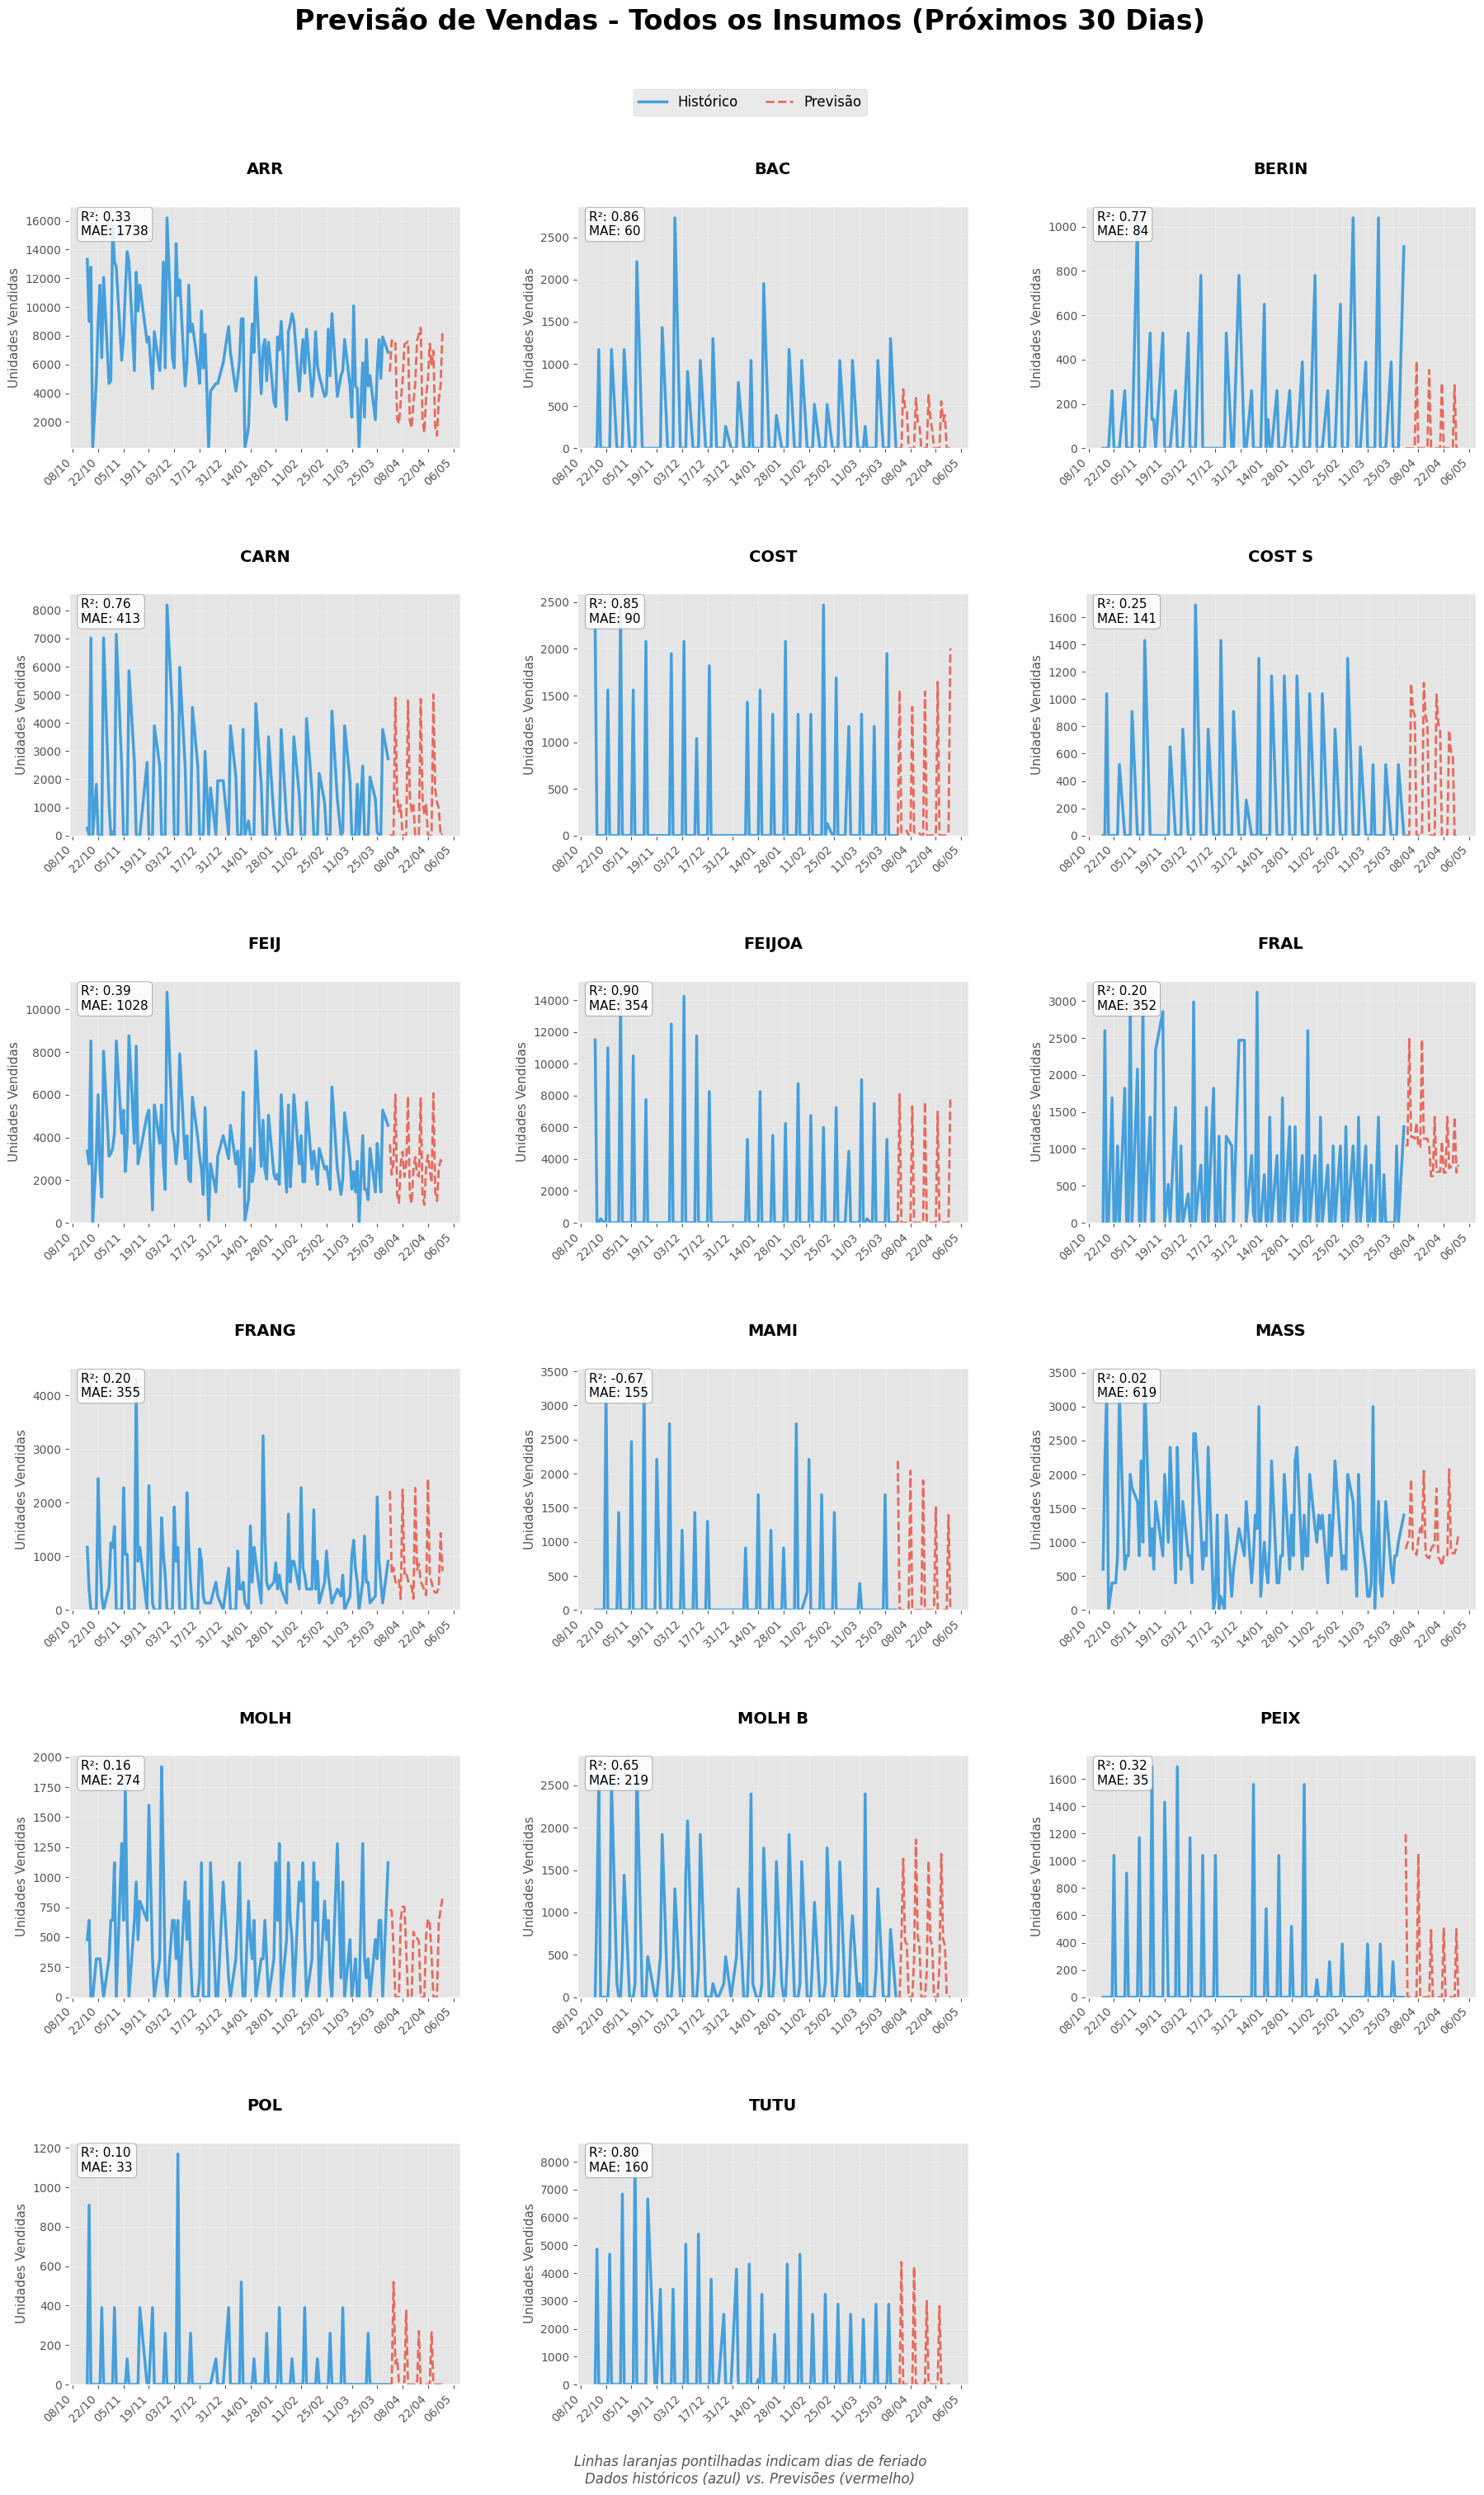

In [68]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.ticker import AutoLocator

# Verificar e usar um estilo disponível
print("Estilos disponíveis:", plt.style.available)  # Mostra todos os estilos instalados
plt.style.use('ggplot')  # Usando um estilo que existe em todas as instalações

# Configurações de estilo profissional
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette("husl")  # Paleta de cores harmoniosa

# Configuração da figura
fig = plt.figure(figsize=(22, 30))
fig.suptitle('Previsão de Vendas - Todos os Insumos (Próximos 30 Dias)',
             fontsize=24, y=1.02, fontweight='bold')

# Layout organizado com espaçamento ampliado
gs = fig.add_gridspec(6, 3, hspace=0.6, wspace=0.3)  # Mais espaço entre gráficos

# Paleta de cores consistente
cor_historico = '#3498db'  # Azul profissional
cor_previsao = '#e74c3c'   # Vermelho profissional
cor_feriado = '#f39c12'    # Laranja para destaque

for idx, insumo in enumerate(insumos):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    
    # Dados históricos
    ax.plot(df['Data'], df[insumo],
            label='Histórico',
            color=cor_historico,
            linewidth=2.5,
            alpha=0.9)
    
    # Previsões
    ax.plot(future_df['Data'], future_df[f'{insumo}_Previsto'],
            label='Previsão',
            color=cor_previsao,
            linestyle='--',
            linewidth=2,
            alpha=0.8)
    
    # Destacar feriados
    for data in future_df[future_df['Feriado'] == 1]['Data']:
        ax.axvline(x=data, color=cor_feriado, linestyle=':', alpha=0.7, linewidth=1.5)
    
    # Formatação dos eixos
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    
    ax.yaxis.set_major_locator(AutoLocator())
    plt.setp(ax.get_yticklabels(), fontsize=10)
    
    # Título e rótulos
    ax.set_title(f'{insumo}\n', fontsize=14, pad=12, fontweight='semibold')
    ax.set_ylabel('Unidades Vendidas', fontsize=11)
    
    # Limites do eixo Y
    y_min = min(df[insumo].min(), future_df[f'{insumo}_Previsto'].min()) * 0.95
    y_max = max(df[insumo].max(), future_df[f'{insumo}_Previsto'].max()) * 1.05
    ax.set_ylim(y_min, y_max)
    
    # Box de métricas
    metric_text = f"R²: {resultados[insumo]['r2']:.2f}\nMAE: {resultados[insumo]['mae']:.0f}"
    ax.text(0.03, 0.88, metric_text,
            transform=ax.transAxes,
            bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray', boxstyle='round,pad=0.3'),
            fontsize=11)

# Apenas uma legenda para todos os gráficos
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 0.99),
           frameon=True, fontsize=12)

# Nota de rodapé
fig.text(0.5, 0.02,
        'Linhas laranjas pontilhadas indicam dias de feriado\nDados históricos (azul) vs. Previsões (vermelho)',
        ha='center', fontsize=12, style='italic', color='#555555')

# Ajuste final
plt.subplots_adjust(top=0.94, bottom=0.06)

# Exportar
plt.savefig('previsoes_insumos_final.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

In [71]:
def gerar_relatorio_compras_simples(insumos, future_df, resultados, dias_previsao=30):
    # Mapeamento completo com unidades de medida
    insumos_info = {
        'ARR': {'nome': 'Arroz', 'unidade': 'kg', 'conversao': 1},
        'BAC': {'nome': 'Bacon', 'unidade': 'kg', 'conversao': 1},
        'BERIN': {'nome': 'Berinjela', 'unidade': 'kg', 'conversao': 1},
        'CARN': {'nome': 'Carne bovina', 'unidade': 'kg', 'conversao': 1},
        'COST': {'nome': 'Costela bovina', 'unidade': 'kg', 'conversao': 1},
        'COST_S': {'nome': 'Costela suína', 'unidade': 'kg', 'conversao': 1},
        'FEU': {'nome': 'Feijão', 'unidade': 'kg', 'conversao': 1},
        'FEUOA': {'nome': 'Feijoada completa', 'unidade': 'kg', 'conversao': 1},
        'FRAL': {'nome': 'Fraldinha', 'unidade': 'kg', 'conversao': 1},
        'FRANG': {'nome': 'Frango', 'unidade': 'kg', 'conversao': 1},
        'MAMI': {'nome': 'Macarrão integral', 'unidade': 'g', 'conversao': 1000},
        'MASS': {'nome': 'Macarrão tradicional', 'unidade': 'g', 'conversao': 1000},
        'MOLH': {'nome': 'Molho de tomate', 'unidade': 'ml', 'conversao': 1},
        'MOLH_B': {'nome': 'Molho branco', 'unidade': 'ml', 'conversao': 1},
        'PEIX': {'nome': 'Filé de peixe', 'unidade': 'kg', 'conversao': 1},
        'POL': {'nome': 'Polenta', 'unidade': 'g', 'conversao': 1000},
        'TUTU': {'nome': 'Tutu de feijão', 'unidade': 'kg', 'conversao': 1}
    }

    # Cálculos básicos convertidos para unidades adequadas
    dados = {}
    for insumo in insumos:
        info = insumos_info.get(insumo, {'nome': insumo, 'unidade': 'un', 'conversao': 1})
        total = future_df[f'{insumo}_Previsto'].sum() / info['conversao']
        media = total / dias_previsao
        estoque_min = max(media * 2, 0.5)  # 2 dias de estoque, mínimo de 0.5 unidade
        
        dados[insumo] = {
            'nome': info['nome'],
            'total': round(total, 2),
            'media': round(media, 2),
            'estoque_min': round(estoque_min, 2),
            'unidade': info['unidade']
        }
    
    # Ordenar por maior consumo
    insumos_ordenados = sorted(insumos, key=lambda x: -dados[x]['total'])
    
    # Cabeçalho explicativo
    print("\n" + "="*80)
    print("PLANEJAMENTO DE COMPRAS PARA O PRÓXIMO MÊS".center(80))
    print("="*80)
    print(f"Período: {future_df['Data'].min().strftime('%d/%m/%Y')} a {future_df['Data'].max().strftime('%d/%m/%Y')}")
    print(f"Relatório gerado em: {pd.Timestamp.now().strftime('%d/%m/%Y %H:%M')}\n")
    
    print("LEGENDA:")
    print("- Média/dia: Quantidade usada por dia em condições normais")
    print("- Estoque mínimo: Quantidade que deve SEMPRE ter na despensa")
    print("- Feriados: Dias que precisam de 20% a mais de ingredientes")
    print("-"*80 + "\n")
    
    # Tabela principal simplificada
    print("LISTA DE COMPRAS NECESSÁRIAS:")
    print("-"*80)
    for insumo in insumos_ordenados:
        d = dados[insumo]
        print(f"{d['nome']}:")
        print(f"  → Total para {dias_previsao} dias: {d['total']} {d['unidade']}")
        print(f"  → Média por dia: {d['media']} {d['unidade']}")
        print(f"  → Estoque mínimo: {d['estoque_min']} {d['unidade']} (sempre ter essa quantidade)\n")
    
    # Feriados destacados
    feriados = future_df[future_df['Feriado'] == 1]['Data']
    if not feriados.empty:
        print("\n" + "ATENÇÃO PARA OS FERIADOS:".center(80))
        print("-"*80)
        print("Nestes dias você vai precisar de 20% a mais destes ingredientes:")
        for data in feriados:
            print(f"  • {data.strftime('%A, %d/%m/%Y')}")
        
        print("\nExemplo: Se usa 10 kg por dia, compre 12 kg para o feriado")
    
    # Rodapé com dicas
    print("\n" + "DICAS IMPORTANTES:".center(80))
    print("-"*80)
    print("1. Compre primeiro os itens com maiores quantidades (listados no topo)")
    print("2. Nunca deixe seu estoque ficar abaixo do mínimo indicado")
    print("3. Para ingredientes em gramas (g): 1000g = 1kg")
    print("4. Líquidos (ml) equivalem a gramas (1ml = 1g)")
    print("="*80 + "\n")

# Chamada da função
gerar_relatorio_compras_simples(insumos, future_df, resultados)


                   PLANEJAMENTO DE COMPRAS PARA O PRÓXIMO MÊS                   
Período: 01/04/2025 a 30/04/2025
Relatório gerado em: 05/05/2025 01:52

LEGENDA:
- Média/dia: Quantidade usada por dia em condições normais
- Estoque mínimo: Quantidade que deve SEMPRE ter na despensa
- Feriados: Dias que precisam de 20% a mais de ingredientes
--------------------------------------------------------------------------------

LISTA DE COMPRAS NECESSÁRIAS:
--------------------------------------------------------------------------------
Arroz:
  → Total para 30 dias: 150949.8 kg
  → Média por dia: 5031.66 kg
  → Estoque mínimo: 10063.32 kg (sempre ter essa quantidade)

FEIJ:
  → Total para 30 dias: 81063.6 un
  → Média por dia: 2702.12 un
  → Estoque mínimo: 5404.24 un (sempre ter essa quantidade)

FEIJOA:
  → Total para 30 dias: 38010.0 un
  → Média por dia: 1267.0 un
  → Estoque mínimo: 2534.0 un (sempre ter essa quantidade)

Carne bovina:
  → Total para 30 dias: 33230.6 kg
  → Média por di